# Morphogenetic media — pattern growth shaped by chords

The `morphogenetic` family runs an iterative pattern-formation process
whose **parameters** depend on the chord. The result is a 2-D scalar
field whose final morphology is a fingerprint of the input chord —
crystal branches, Turing patterns, etc.


In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# A small reference set of chord inputs used across the notebook.
CHORDS = {
    "Major": HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)]),
    "Sus4":  HarmonicInput(ratios=[Fraction(1), Fraction(4, 3), Fraction(3, 2)]),
    "Dom7":  HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                                    Fraction(3, 2), Fraction(7, 4)]),
    "Dim7":  HarmonicInput(ratios=[Fraction(1), Fraction(6, 5),
                                    Fraction(7, 5), Fraction(12, 7)]),
}


## `Crystallization` — snowflake-style chord growth

A reaction-diffusion-like process on a hex grid; the anisotropy strength
and number of sectors are derived from the chord ratios. Higher chord
complexity → more elaborate branching.

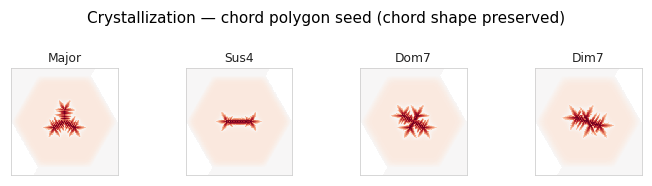

In [2]:
from biotuner.harmonic_geometry.media import Crystallization

# The polygon seed plants a small V-blob at every Tonnetz-polygon vertex
# of the chord. With ``seed_branch_length > 0`` each seed is extended
# along the polygon edges, so the resulting crystal silhouette carries
# the chord's polygonal signature — Major reads as a triangle with
# branches, Sus4 as an elongated triad, Dom7 / Dim7 as four-pointed
# motifs. ``anisotropy_strength=0`` turns off the angular kernel bias
# so the chord polygon, not the lattice, drives symmetry.
chord_crystal = Crystallization(
    n_steps=1500, grid_radius=130, output_resolution=256,
    seed_strategy="polygon", seed_branch_length=6,
    anisotropy_strength=0.0, rng_seed=0,
)
geoms = [chord_crystal(CHORDS[n]) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="Crystallization — chord polygon seed (chord shape preserved)");


### Sweep `diffusion` on a single central seed

With a single central seed and no chord-polygon to bias the shape, the
underlying triangular Reiter lattice produces the classic six-armed
snowflake. ``diffusion`` then controls how far latent water can spread
between freezing steps — low diffusion gives a small compact crystal,
high diffusion gives sparser, more ramified dendrites of the same
6-fold symmetry.

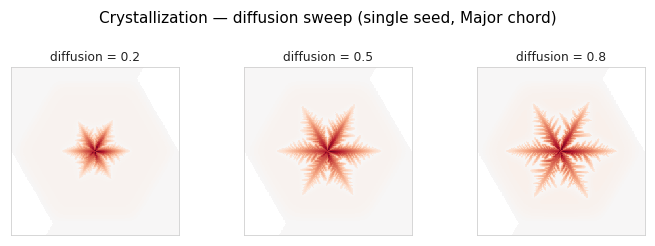

In [3]:
diffusions = [0.2, 0.5, 0.8]
geoms = [Crystallization(n_steps=4000, grid_radius=150,
                          output_resolution=256,
                          seed_strategy="single", diffusion=d,
                          rng_seed=0)(CHORDS["Major"])
         for d in diffusions]
plotting.gallery(geoms,
                 titles=[f"diffusion = {d}" for d in diffusions], n_cols=3,
                 suptitle="Crystallization — diffusion sweep (single seed, Major chord)");


## `ReactionDiffusion` — chord-driven Gray-Scott patterns

Standard Gray-Scott $(U, V)$ kinetics where ``feed`` and ``kill`` rates
are derived from the chord (or supplied explicitly). The output is the
``v``-species concentration after ``n_steps`` updates — spots, stripes,
mazes, or fingerprint depending on where the chord places you in
parameter space.

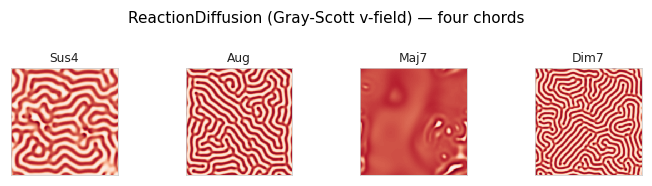

In [4]:
from biotuner.harmonic_geometry.media import ReactionDiffusion

# The chord-derived F/K range is broad — some chords land in regions
# of the Pearson plane where V dies out (uniform-red attractor). The
# four below all map into the *active* labyrinth band so the chord
# differences read cleanly:
#   Sus4 → fine maze with stripe segments
#   Aug  → coarser maze
#   Maj7 → asymmetric stripes
#   Dim7 → tight bubble field (chord with the densest seed polygon)
active = {
    "Sus4":  CHORDS["Sus4"],
    "Aug":   HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(8, 5)]),
    "Maj7":  HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                                    Fraction(3, 2), Fraction(15, 8)]),
    "Dim7":  CHORDS["Dim7"],
}
rd    = ReactionDiffusion(n_steps=10000, resolution=192, rng_seed=0)
geoms = [rd(c) for c in active.values()]
plotting.gallery(geoms, titles=list(active.keys()), n_cols=4,
                 suptitle="ReactionDiffusion (Gray-Scott v-field) — four chords");


### Canonical Pearson regimes (chord fixed, $(F, K)$ swept)

Holding the chord constant and stepping through the canonical Pearson
$(F, K)$ coordinates visits four qualitatively different attractors:
β-foam, γ-spots, κ-labyrinth, and δ-replicating dots. The central-seed
trigger makes the regimes converge faster than the polygon seed.

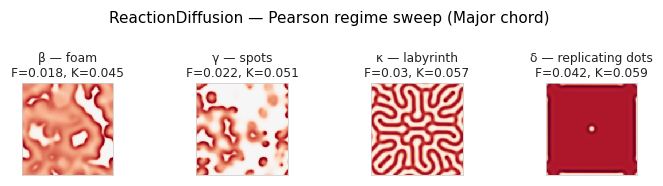

In [5]:
pts = [
    (0.018, 0.045, "β — foam"),
    (0.022, 0.051, "γ — spots"),
    (0.030, 0.057, "κ — labyrinth"),
    (0.042, 0.059, "δ — replicating dots"),
]
geoms = [ReactionDiffusion(n_steps=10000, resolution=160,
                            feed=f, kill=k, seed_strategy="single",
                            rng_seed=0)(CHORDS["Major"])
         for f, k, _ in pts]
plotting.gallery(geoms,
                 titles=[f"{lbl}\nF={f}, K={k}" for f, k, lbl in pts],
                 n_cols=4,
                 suptitle="ReactionDiffusion — Pearson regime sweep (Major chord)");
